# Gradient Boosting Example: Tight End Production Analysis

In this notebook we will leverage our gradient boosting class to better understand if skill statistics determine tight end production. Specifically, we can use stats that measure how skilled a tight end is to predict their overall production. 

There are many times where we see tight ends projected as high producers, but they fall short of these high expectations. We aim to understand if this lack of production is driven by skills or team context and usage.

A prime example of this is Kyle Pitts, Atlanta Falcons TE. After a strong rookie season, Pitts was primed to continue his breakout. He ultimately fell far short of those expectations for the next few years. Our analysis will aim to determine whether his skills are overrated or if his lack of production was due to the Falcons under-utilization of their potential star TE.

In [32]:
# Import necessary libraries
import sys
import os

# Send Python to the project root so we can import our library
project_root = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/src"
sys.path.append(project_root)

# Import our ML library and other necessary libraries
import rice_ml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
# Import the dataset
data_path = "/Users/maxbasurto/Documents/Rice Classes/CMOR 438/CMOR438-Project/data/tightend_data.csv"
data = pd.read_csv(data_path)

Now that we have the data loaded we can prepare it for the model.

Our goal is to predict total receiving yards using the following features: yards after the catch per catch (YAC/REC), completion percetange when targeted (COMP%), yards per route run (YPRR).

This set of features help define a tight end's skills rather than their pure production. We looked at efficiency metrics (YAC/REC and YPRR) to better understand the skill of the tight end, regardless of their volume. To round out our feature set we use COMP% to identify the rate at which a player catches the ball. Together, this set of features captures a tight end's receiving skillset independent of their overall production.

We use this skillset to see if we can predict overall production. We select total receiving yards as our production metric because it captures volume, type of usage (short, medium, long distances), and efficiency.

In [58]:
# Filter out potential outliers using minimum snaps threshold
min_snaps = 20
data = data[data['REC SNP'] >= min_snaps]

# Add completion percentage feature
data['COMp'] = data['REC'] / data['TGT']

# Select features and target variable
features = ['YPRR', 'YAC/REC', 'COMp']
target = 'REC YDS'

# Select the relevant columns, keeping as a DataFrame for consistency
X = data[features]
y = data[target]


# Show the first few rows of the features dataset
print(X.head())

   YPRR  YAC/REC      COMp
1  1.29      2.4  0.675000
2  1.39      5.6  0.719626
3  1.75      2.8  0.694444
5  1.57      5.3  0.704762
6  1.13      4.4  0.705882


This data cleaning yields two key dataframes for our analysis. One with the features and one with the response variable. Now we are closer to being ready for training. The final step is to standardize the data, making the data have unified units instead of two with the unit of yards and one being a probability.

In [59]:
# Standardize the features using our library's standard scaler class
scaler = rice_ml.StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 80% of the data for training and 20% for testing
indices = X_scaled.index
shuffled_indices = X_scaled.sample(frac=1, random_state=42).index
X_shuffled = X_scaled.loc[shuffled_indices].reset_index(drop=True)
y_shuffled = y.loc[shuffled_indices].reset_index(drop=True)
train_size = int(0.8 * len(X_shuffled))
train_data = X_shuffled.iloc[:train_size]
train_y = y_shuffled.iloc[:train_size]
test_data = X_shuffled.iloc[train_size:]
test_y = y_shuffled.iloc[train_size:]

# Train a gradient boosting regressor using our library
model = rice_ml.GradientBoostingRegressor(n_estimators=80, learning_rate=0.01, max_depth=2)
model.train(train_data.values, train_y.values)

Now that we have trained the model we can use it to make predictions on the test set and evaluate the model's effectiveness.

In [60]:
# Make predictions on the test set
predictions = model.predict(test_data.values)

# Evaluate the model using mean squared error, mean absolute error, and R-squared from our library
mse = rice_ml.mean_squared_error(test_y.values, predictions)
mae = rice_ml.mean_absolute_error(test_y.values, predictions)
r2 = rice_ml.r_squared_score(test_y.values, predictions)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

Mean Squared Error: 48459.362648123686
Mean Absolute Error: 182.5929668793133
R-squared: 0.26479297189694573


Our model successfully explains about 26% of the variance in receiving yards, telling us that tight end skill isn't driving their production significantly. Of course, our metrics don't completely capture a tight end's skillset, but they do help us understand that tight end production may hinge more heavily on their team's scheme.

These results make sense because tight end is a very versatile position and teams use their tight ends in a variety of ways. Some teams lean on their tight ends heavily as blockers, so high skill tight end production would be limited in these systems. Others lineup up their tight ends in the slot a lot, leaving room for less skilled tight ends to produce at a high level.

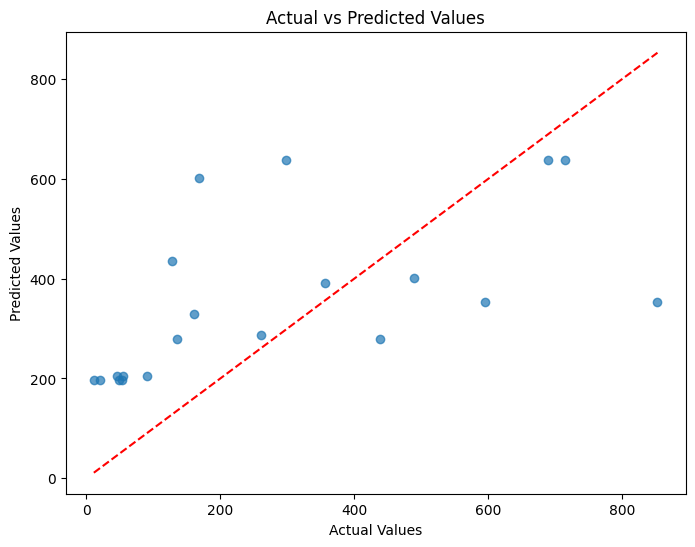

In [61]:
# Create a scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(test_y.values, predictions, alpha=0.7)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

The graph above shows the actual values compared to our model's predictions. Dots far above the perfect accuracy line (dotted line where actual equals predicted) are likely underutilized, high skill players. The contrast is true for points far below the line: these are players overperforming relative to their skill, likely due to high volume usage.

Ultimately, we aren't able to develop a strong skill to production gradient boosting model, demonstrating how tight end production is based in many areas outside of their control.